# DIF Simulation: Dichotomous Responses
## Rasch / IRT-based DIF Analysis with Stan & CmdStanPy

This notebook simulates a realistic dichotomous response dataset from two groups of Korean language learners and uses **Bayesian IRT models** (Rasch 1PL with uniform DIF) implemented in **Stan** via **CmdStanPy** to detect and quantify **Differential Item Functioning (DIF)**.

**Research context:**  
Two student groups take the same Korean language proficiency test:
- **Group 0 (Reference):** Domestic undergraduate students (Korean exposure in Korea)  
- **Group 1 (Focal):** Overseas graduate students (limited Korean immersion, e.g., students in India)

Known DIF is injected into select items to evaluate recovery accuracy.

---

**Model overview:**

| Model | Formula |
|-------|---------|
| Rasch (baseline) | $P(X_{ij}=1) = \dfrac{1}{1+e^{-(\theta_i - \beta_j)}}$ |
| DIF (uniform) | $P(X_{ij}=1) = \dfrac{1}{1+e^{-(\theta_i - \beta_j - \delta_j \cdot g_i)}}$ |

$\delta_j > 0$: item $j$ is harder for the focal group; $\delta_j < 0$: easier for focal group.

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, warnings
from pathlib import Path
from scipy.special import expit   # logistic / sigmoid function
from matplotlib import font_manager as fm

# CmdStanPy
from cmdstanpy import CmdStanModel

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="muted")

# ---------- reproducibility ----------
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# ---------- matplotlib Korean font setup ----------
def set_korean_font():
    # Try common Korean fonts in order of preference.
    candidates = [
        "AppleGothic",          # macOS
        "NanumGothic",          # common on many systems
        "Noto Sans CJK KR",     # Google/Adobe CJK
        "Noto Sans KR",
        "Malgun Gothic",        # Windows
        "Arial Unicode MS",     # broad Unicode fallback
    ]
    available_fonts = {f.name for f in fm.fontManager.ttflist}
    for font_name in candidates:
        if font_name in available_fonts:
            mpl.rcParams["font.family"] = font_name
            mpl.rcParams["axes.unicode_minus"] = False
            return font_name
    mpl.rcParams["axes.unicode_minus"] = False
    return None

selected_font = set_korean_font()

print("NumPy      :", np.__version__)
print("Pandas     :", pd.__version__)
try:
    import cmdstanpy
    print("CmdStanPy  :", cmdstanpy.__version__)
except Exception as e:
    print("CmdStanPy  : not found —", e)

if selected_font:
    print("Matplotlib : Korean font set to", selected_font)
else:
    print("Matplotlib : No Korean font found. Install 'NanumGothic' or 'Noto Sans KR'.")

NumPy      : 1.26.4
Pandas     : 2.3.1
CmdStanPy  : 1.2.5
Matplotlib : Korean font set to Malgun Gothic


## 2. Simulate Dichotomous Response Data (Korean Language Items)

We simulate a **20-item Korean language test** taken by two groups of learners.  
Five items have **known DIF** injected (`δ_j ≠ 0`); the rest are DIF-free (`δ_j = 0`).

**True generating model (Rasch + uniform DIF):**

$$P(X_{ij}=1 \mid \theta_i, \beta_j, \delta_j, g_i) = \frac{1}{1 + e^{-(\theta_i - \beta_j - \delta_j \cdot g_i)}}$$

| Parameter | Description |
|-----------|-------------|
| $\theta_i$ | Student ability |
| $\beta_j$ | Item difficulty |
| $\delta_j$ | DIF parameter (group difference in difficulty) |
| $g_i$ | Group indicator (0 = reference, 1 = focal) |

In [2]:
# ── Simulation settings ──────────────────────────────────────────────────────
N_REF   = 150   # reference group: domestic undergrads
N_FOCAL = 120   # focal group:    overseas grad students
N_ITEMS = 20    # number of test items

# ── True item difficulty (beta) ───────────────────────────────────────────────
# Range: -2 to 2 (logit scale).  Items cover vocabulary, grammar, reading, etc.
true_beta = np.array([-1.8, -1.4, -1.0, -0.8, -0.5,
                      -0.3,  0.0,  0.2,  0.4,  0.6,
                       0.7,  0.9,  1.0,  1.2,  1.4,
                       1.6,  1.8,  0.1, -0.6,  0.3])

# ── True DIF parameters (delta) ───────────────────────────────────────────────
# δ_j > 0  →  item harder for focal group (overseas students)
# δ_j = 0  →  no DIF
DIF_ITEMS = {
    3:  +0.90,   # Item 4  – 한자어 vocabulary (sinitic vocab, harder for non-CJK)
    9:  +1.10,   # Item 10 – traditional culture reading (옹기, 발효)
    10: +0.70,   # Item 11 – academic register listening
    16: -0.80,   # Item 17 – phonetic discrimination (easier outside Korea)
    19: +1.20,   # Item 20 – complex honorifics usage
}
true_delta = np.zeros(N_ITEMS)
for idx, val in DIF_ITEMS.items():
    true_delta[idx] = val

# ── Student abilities ─────────────────────────────────────────────────────────
theta_ref   = rng.normal(loc= 0.3, scale=1.0, size=N_REF)   # more immersion
theta_focal = rng.normal(loc=-0.4, scale=1.1, size=N_FOCAL)  # less immersion

# ── Simulate responses ────────────────────────────────────────────────────────
def simulate_responses(theta, beta, delta, group_id):
    n, m = len(theta), len(beta)
    probs = expit(theta[:, None] - beta[None, :] - delta[None, :] * group_id)
    responses = rng.binomial(1, probs)
    df = pd.DataFrame(responses, columns=[f"item{j+1:02d}" for j in range(m)])
    df.insert(0, "group", group_id)
    df.insert(0, "student_id",
              range(1, n+1) if group_id == 0 else range(N_REF+1, N_REF+n+1))
    return df

df_ref   = simulate_responses(theta_ref,   true_beta, true_delta, group_id=0)
df_focal = simulate_responses(theta_focal, true_beta, true_delta, group_id=1)
df_all   = pd.concat([df_ref, df_focal], ignore_index=True)

print(f"Total students : {len(df_all)} (ref={N_REF}, focal={N_FOCAL})")
print(f"Items          : {N_ITEMS}")
print(f"True DIF items : indices {list(DIF_ITEMS.keys())} → items {[k+1 for k in DIF_ITEMS]}")
print("\n--- First 5 rows ---")
df_all.head()

Total students : 270 (ref=150, focal=120)
Items          : 20
True DIF items : indices [3, 9, 10, 16, 19] → items [4, 10, 11, 17, 20]

--- First 5 rows ---


,student_id,group,item01,item02,item03,item04,item05,item06,item07,item08,...,item11,item12,item13,item14,item15,item16,item17,item18,item19,item20
0,1,0,1,1,1,1,1,1,1,1,...,0,1,0,1,0,1,1,0,0,0
1,2,0,1,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
2,3,0,0,1,1,1,1,0,1,0,...,1,0,1,1,1,0,0,1,1,1
3,4,0,1,1,0,1,1,1,0,0,...,1,0,1,0,1,0,0,0,1,1
4,5,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [3]:
# ── True parameter summary table ──────────────────────────────────────────────
item_labels = [
    "듣기 01 – basic greeting",     "듣기 02 – daily dialogue",
    "듣기 03 – classroom vocab",    "듣기 04 – 한자어 vocab ★DIF",
    "조사 05 – particles",           "조사 06 – connectives",
    "어휘 07 – context meaning",    "어휘 08 – synonyms",
    "어휘 09 – register",            "읽기 10 – culture text ★DIF",
    "읽기 11 – academic register ★DIF", "읽기 12 – news article",
    "읽기 13 – essay structure",    "읽기 14 – argumentation",
    "듣기 15 – lecture",             "듣기 16 – announcement",
    "기능 17 – phonetics ★DIF",     "문법 18 – tense usage",
    "문법 19 – negation",            "경어 20 – honorifics ★DIF",
]

params_df = pd.DataFrame({
    "item"              : [f"item{j+1:02d}" for j in range(N_ITEMS)],
    "description"       : item_labels,
    "true_beta"         : np.round(true_beta, 2),
    "true_delta (DIF)"  : np.round(true_delta, 2),
    "DIF?"              : ["★ DIF" if true_delta[j] != 0 else "" for j in range(N_ITEMS)],
})
params_df

,item,description,true_beta,true_delta (DIF),DIF?
0,item01,듣기 01 – basic greeting,-1.8,0.0,
1,item02,듣기 02 – daily dialogue,-1.4,0.0,
2,item03,듣기 03 – classroom vocab,-1.0,0.0,
3,item04,듣기 04 – 한자어 vocab ★DIF,-0.8,0.9,★ DIF
4,item05,조사 05 – particles,-0.5,0.0,
5,item06,조사 06 – connectives,-0.3,0.0,
6,item07,어휘 07 – context meaning,0.0,0.0,
7,item08,어휘 08 – synonyms,0.2,0.0,
8,item09,어휘 09 – register,0.4,0.0,
9,item10,읽기 10 – culture text ★DIF,0.6,1.1,★ DIF


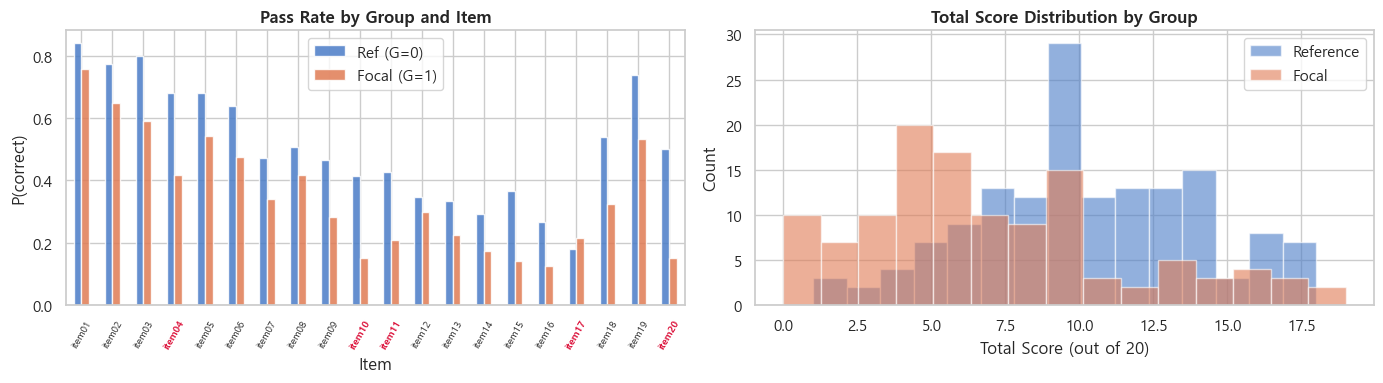

Δ pass-rate table (Reference minus Focal, positive = harder for focal):
        Ref (G=0)  Focal (G=1)  Δ (Ref−Focal)
item01   0.840000     0.758333          0.082
item02   0.773333     0.650000          0.123
item03   0.800000     0.591667          0.208
item04   0.680000     0.416667          0.263
item05   0.680000     0.541667          0.138
item06   0.640000     0.475000          0.165
item07   0.473333     0.341667          0.132
item08   0.506667     0.416667          0.090
item09   0.466667     0.283333          0.183
item10   0.413333     0.150000          0.263
item11   0.426667     0.208333          0.218
item12   0.346667     0.300000          0.047
item13   0.333333     0.225000          0.108
item14   0.293333     0.175000          0.118
item15   0.366667     0.141667          0.225
item16   0.266667     0.125000          0.142
item17   0.180000     0.216667         -0.037
item18   0.540000     0.325000          0.215
item19   0.740000     0.533333          0.207
item20  

In [4]:
# ── Descriptive statistics by group ───────────────────────────────────────────
item_cols = [c for c in df_all.columns if c.startswith("item")]

desc = df_all.groupby("group")[item_cols].mean().T
desc.columns = ["Ref (G=0)", "Focal (G=1)"]
desc["Δ (Ref−Focal)"] = (desc["Ref (G=0)"] - desc["Focal (G=1)"]).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Item-level pass rates
desc[["Ref (G=0)", "Focal (G=1)"]].plot(kind="bar", ax=axes[0],
    color=["#4a7cc7", "#e07b54"], alpha=0.85, edgecolor="white")
axes[0].set_title("Pass Rate by Group and Item", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Item")
axes[0].set_ylabel("P(correct)")
axes[0].tick_params(axis="x", rotation=60, labelsize=7)
for j in DIF_ITEMS:
    tick = axes[0].get_xticklabels()[j]
    tick.set_color("crimson")
    tick.set_fontweight("bold")

# Score distributions
df_all["total_score"] = df_all[item_cols].sum(axis=1)
for g, color, label in [(0, "#4a7cc7", "Reference"), (1, "#e07b54", "Focal")]:
    subset = df_all[df_all.group == g]["total_score"]
    axes[1].hist(subset, bins=15, alpha=0.6, color=color, label=label, edgecolor="white")
axes[1].set_title("Total Score Distribution by Group", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Total Score (out of 20)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("desc_stats.png", dpi=120, bbox_inches="tight")
plt.show()
print("Δ pass-rate table (Reference minus Focal, positive = harder for focal):")
print(desc.to_string())

## 3. Define Rasch Model in Stan (Baseline — No DIF)

The baseline **Rasch model** assumes item difficulties are identical for both groups:

$$\log\left(\frac{P}{1-P}\right) = \theta_i - \beta_j$$

**Priors:**
- $\theta_i \sim \mathcal{N}(0, 1)$ — student ability (mean-zero anchor)
- $\beta_j \sim \mathcal{N}(0, 1)$ — item difficulty (weakly informative)

The generated quantities block computes pointwise log-likelihood for model comparison (WAIC / LOO-CV).

In [5]:
STAN_DIR = Path("stan_models")
STAN_DIR.mkdir(exist_ok=True)

rasch_code = """
data {
  int<lower=1> N;          // number of students
  int<lower=1> J;          // number of items
  array[N, J] int<lower=0, upper=1> Y;  // response matrix (0/1)
}
parameters {
  vector[N] theta;          // student ability
  vector[J] beta;           // item difficulty
}
model {
  // priors
  theta ~ normal(0, 1);
  beta  ~ normal(0, 3);

  // likelihood
  for (i in 1:N)
    for (j in 1:J)
      Y[i, j] ~ bernoulli_logit(theta[i] - beta[j]);
}
generated quantities {
  // pointwise log-likelihood for model comparison (WAIC/LOO)
  matrix[N, J] log_lik;
  for (i in 1:N)
    for (j in 1:J)
      log_lik[i, j] = bernoulli_logit_lpmf(Y[i, j] | theta[i] - beta[j]);
}
"""

rasch_path = STAN_DIR / "rasch_1pl.stan"
rasch_path.write_text(rasch_code.strip())
print(f"Stan model saved:  {rasch_path}")
print()
print(rasch_code)

Stan model saved:  stan_models\rasch_1pl.stan


data {
  int<lower=1> N;          // number of students
  int<lower=1> J;          // number of items
  array[N, J] int<lower=0, upper=1> Y;  // response matrix (0/1)
}
parameters {
  vector[N] theta;          // student ability
  vector[J] beta;           // item difficulty
}
model {
  // priors
  theta ~ normal(0, 1);
  beta  ~ normal(0, 3);

  // likelihood
  for (i in 1:N)
    for (j in 1:J)
      Y[i, j] ~ bernoulli_logit(theta[i] - beta[j]);
}
generated quantities {
  // pointwise log-likelihood for model comparison (WAIC/LOO)
  matrix[N, J] log_lik;
  for (i in 1:N)
    for (j in 1:J)
      log_lik[i, j] = bernoulli_logit_lpmf(Y[i, j] | theta[i] - beta[j]);
}



## 4. Define DIF Model in Stan (Uniform DIF)

The **DIF model** adds a per-item group-difficulty-shift parameter $\delta_j$:

$$\log\left(\frac{P}{1-P}\right) = \theta_i - \beta_j - \delta_j \cdot g_i$$

| $\delta_j$ | Interpretation |
|------------|----------------|
| $= 0$ | No DIF on item $j$ |
| $> 0$ | Item $j$ harder for focal group |
| $< 0$ | Item $j$ easier for focal group |

**Prior:** $\delta_j \sim \mathcal{N}(0, 1)$ — weakly regularising, centred at zero (no DIF)

**Bayesian DIF detection criterion** (practical significance):

$$P(|\delta_j| \geq 0.2) \geq 0.80 \Rightarrow \text{flag item } j \text{ as DIF}$$

In [6]:
dif_code = """
data {
  int<lower=1> N;                        // number of students
  int<lower=1> J;                        // number of items
  array[N, J] int<lower=0, upper=1> Y;   // response matrix (0/1)
  array[N] int<lower=0, upper=1> group;  // 0 = reference, 1 = focal
}
parameters {
  vector[N] theta;   // student ability
  vector[J] beta;    // baseline item difficulty (reference group)
  vector[J] delta;   // uniform DIF: difficulty shift for focal group
}
model {
  // priors
  theta ~ normal(0, 1);
  beta  ~ normal(0, 3);
  delta ~ normal(0, 1);   // weakly regularising; centred at no DIF

  // likelihood
  for (i in 1:N)
    for (j in 1:J)
      Y[i, j] ~ bernoulli_logit(theta[i] - beta[j] - delta[j] * group[i]);
}
generated quantities {
  matrix[N, J] log_lik;
  for (i in 1:N)
    for (j in 1:J)
      log_lik[i, j] = bernoulli_logit_lpmf(
        Y[i, j] | theta[i] - beta[j] - delta[j] * group[i]);
}
"""

dif_path = STAN_DIR / "dif_rasch.stan"
dif_path.write_text(dif_code.strip())
print(f"Stan model saved:  {dif_path}")
print()
print(dif_code)

Stan model saved:  stan_models\dif_rasch.stan


data {
  int<lower=1> N;                        // number of students
  int<lower=1> J;                        // number of items
  array[N, J] int<lower=0, upper=1> Y;   // response matrix (0/1)
  array[N] int<lower=0, upper=1> group;  // 0 = reference, 1 = focal
}
parameters {
  vector[N] theta;   // student ability
  vector[J] beta;    // baseline item difficulty (reference group)
  vector[J] delta;   // uniform DIF: difficulty shift for focal group
}
model {
  // priors
  theta ~ normal(0, 1);
  beta  ~ normal(0, 3);
  delta ~ normal(0, 1);   // weakly regularising; centred at no DIF

  // likelihood
  for (i in 1:N)
    for (j in 1:J)
      Y[i, j] ~ bernoulli_logit(theta[i] - beta[j] - delta[j] * group[i]);
}
generated quantities {
  matrix[N, J] log_lik;
  for (i in 1:N)
    for (j in 1:J)
      log_lik[i, j] = bernoulli_logit_lpmf(
        Y[i, j] | theta[i] - beta[j] - delta[j] * group[i]);
}



## 5. Fit Baseline Rasch Model with CmdStanPy

Compile and sample from the Rasch model (no DIF). This serves as a convergence check and baseline for LOO model comparison.

In [7]:
# ── Prepare data for Stan (2-D array of ints) ─────────────────────────────────
Y_array = df_all[item_cols].values.tolist()   # list of lists

stan_data_rasch = {
    "N": int(len(df_all)),
    "J": int(N_ITEMS),
    "Y": Y_array,
}

# ── Compile ───────────────────────────────────────────────────────────────────
print("Compiling Rasch model …")
rasch_model = CmdStanModel(stan_file=str(rasch_path))
print("Compilation complete.\n")

# ── Sample ────────────────────────────────────────────────────────────────────
print("Sampling (Rasch baseline, 4 chains × 1000 post-warmup) …")
rasch_fit = rasch_model.sample(
    data        = stan_data_rasch,
    chains      = 4,
    iter_warmup = 1000,
    iter_sampling = 1000,
    seed        = RNG_SEED,
    show_progress = True,
    adapt_delta = 0.90,
)
print("\nSampling complete.")

20:53:00 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\Downloads\KOS5101\dif\stan_models\rasch_1pl.stan to exe file C:\Users\yongd\Downloads\KOS5101\dif\stan_models\rasch_1pl.exe


Compiling Rasch model …


20:53:11 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\Downloads\KOS5101\dif\stan_models\rasch_1pl.exe


Compilation complete.

Sampling (Rasch baseline, 4 chains × 1000 post-warmup) …


20:53:12 - cmdstanpy - INFO - CmdStan start processing


...

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

20:53:43 - cmdstanpy - INFO - CmdStan done processing.




Sampling complete.


In [8]:
# ── Convergence diagnostics (Rasch) ──────────────────────────────────────────
rasch_summary = rasch_fit.summary()

# CmdStanPy version compatibility: old -> N_Eff, new -> ESS_bulk
ess_col = "ESS_bulk" if "ESS_bulk" in rasch_summary.columns else "N_Eff"

beta_rows  = rasch_summary[rasch_summary.index.str.startswith("beta[")]
theta_rows = rasch_summary[rasch_summary.index.str.startswith("theta[")]

print("── Item difficulty (beta) — Rasch baseline diagnostics ──")
print(beta_rows[["Mean", "StdDev", "5%", "95%", "R_hat", ess_col]].to_string())
print(f"\nMax R-hat (beta) : {beta_rows['R_hat'].max():.4f}  (< 1.01 is good)")
print(f"Min {ess_col} (beta) : {beta_rows[ess_col].min():.0f}  (> 400 is acceptable)")

── Item difficulty (beta) — Rasch baseline diagnostics ──
              Mean    StdDev        5%       95%     R_hat  ESS_bulk
beta[1]  -1.714980  0.178833 -2.005290 -1.420660  1.000210   3701.91
beta[2]  -1.150440  0.164777 -1.424370 -0.881982  1.001130   3736.81
beta[3]  -1.086090  0.160822 -1.356040 -0.822639  1.000700   3762.40
beta[4]  -0.317913  0.152296 -0.569045 -0.068000  1.000980   2842.17
beta[5]  -0.599668  0.155424 -0.850533 -0.342246  0.999580   3105.22
beta[6]  -0.333267  0.152212 -0.582698 -0.081091  1.000890   3143.42
beta[7]   0.423954  0.148441  0.180062  0.662745  0.999909   3015.26
beta[8]   0.163029  0.149484 -0.084712  0.409582  1.000680   3066.68
beta[9]   0.576412  0.151551  0.332967  0.821412  1.000420   2960.00
beta[10]  1.061480  0.160857  0.801460  1.333600  1.000880   3114.05
beta[11]  0.870826  0.157021  0.607033  1.134590  1.000380   2941.22
beta[12]  0.891396  0.155100  0.640536  1.152630  1.001450   2746.20
beta[13]  1.125490  0.161296  0.868156  1.401

## 6. Fit DIF Model with CmdStanPy

Augment the data with group indicators and sample from the DIF model. The $\delta_j$ posteriors will reveal which items function differently across groups.

In [9]:
# ── Prepare data (adds group vector) ─────────────────────────────────────────
stan_data_dif = {
    "N"     : int(len(df_all)),
    "J"     : int(N_ITEMS),
    "Y"     : Y_array,
    "group" : df_all["group"].tolist(),
}

# ── Compile ───────────────────────────────────────────────────────────────────
print("Compiling DIF model …")
dif_model = CmdStanModel(stan_file=str(dif_path))
print("Compilation complete.\n")

# ── Sample ────────────────────────────────────────────────────────────────────
print("Sampling (DIF model, 4 chains × 1200 post-warmup) …")
dif_fit = dif_model.sample(
    data          = stan_data_dif,
    chains        = 4,
    iter_warmup   = 1200,
    iter_sampling = 1200,
    seed          = RNG_SEED,
    show_progress = True,
    adapt_delta   = 0.92,
    max_treedepth = 12,
)
print("\nSampling complete.")

20:54:26 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\Downloads\KOS5101\dif\stan_models\dif_rasch.stan to exe file C:\Users\yongd\Downloads\KOS5101\dif\stan_models\dif_rasch.exe


Compiling DIF model …


20:54:36 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\Downloads\KOS5101\dif\stan_models\dif_rasch.exe


Compilation complete.

Sampling (DIF model, 4 chains × 1200 post-warmup) …


20:54:37 - cmdstanpy - INFO - CmdStan start processing


...

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

20:55:36 - cmdstanpy - INFO - CmdStan done processing.




Sampling complete.


In [10]:
# ── Convergence diagnostics (DIF model) ──────────────────────────────────────
dif_summary = dif_fit.summary()

# CmdStanPy version compatibility: old -> N_Eff, new -> ESS_bulk
ess_col = "ESS_bulk" if "ESS_bulk" in dif_summary.columns else "N_Eff"

delta_rows = dif_summary[dif_summary.index.str.startswith("delta[")]
beta_dif   = dif_summary[dif_summary.index.str.startswith("beta[")]

print("── DIF parameter (δ) diagnostics ──")
print(delta_rows[["Mean", "StdDev", "5%", "95%", "R_hat", ess_col]].to_string())
print(f"\nMax R-hat (delta) : {delta_rows['R_hat'].max():.4f}  (< 1.01 is good)")
print(f"Min {ess_col} (delta) : {delta_rows[ess_col].min():.0f}  (> 400 is acceptable)")

── DIF parameter (δ) diagnostics ──
               Mean    StdDev        5%       95%     R_hat  ESS_bulk
delta[1]   0.251767  0.339505 -0.303049  0.808406  1.000530   3381.88
delta[2]   0.399539  0.298633 -0.092022  0.878699  1.003960   3019.56
delta[3]   0.844713  0.301408  0.351754  1.346590  1.001410   2626.43
delta[4]   1.012360  0.289874  0.545136  1.489300  1.000750   2845.83
delta[5]   0.415754  0.285734 -0.036714  0.896105  1.000910   2844.22
delta[6]   0.537613  0.276620  0.083752  0.992441  1.000600   3354.63
delta[7]   0.441113  0.286535 -0.024945  0.906756  1.001400   3583.36
delta[8]   0.212089  0.281761 -0.251745  0.684810  0.999930   3003.56
delta[9]   0.728716  0.293767  0.246507  1.211040  1.001200   3747.42
delta[10]  1.382410  0.333312  0.837359  1.939100  1.002200   3802.19
delta[11]  1.008090  0.306130  0.512047  1.524100  1.001570   3611.49
delta[12]  0.082359  0.299186 -0.411702  0.574006  1.000420   2948.64
delta[13]  0.474777  0.308045 -0.029104  0.982669  0.9

## 7. Extract and Summarise Posterior Estimates

For each parameter we report the posterior mean, SD, and 5th/95th percentile credible interval.  
We also compute $P(|\delta_j| \geq 0.2)$ — the probability the DIF effect exceeds a practically meaningful threshold.

In [11]:
# ── Extract posterior draws ───────────────────────────────────────────────────
draws = dif_fit.draws_pd()

delta_draw_cols = [c for c in draws.columns if c.startswith("delta[")]
beta_draw_cols  = [c for c in draws.columns if c.startswith("beta[")]

# ── Helper: posterior summary dataframe ──────────────────────────────────────
def posterior_summary(draws_df, param_cols, true_vals=None):
    rows = []
    for i, col in enumerate(param_cols):
        s = draws_df[col].values
        row = {
            "parameter"  : col,
            "post_mean"  : s.mean(),
            "post_sd"    : s.std(),
            "q05"        : np.quantile(s, 0.05),
            "q50"        : np.quantile(s, 0.50),
            "q95"        : np.quantile(s, 0.95),
            "P(|δ|≥0.2)" : float((np.abs(s) >= 0.2).mean()),
        }
        if true_vals is not None:
            row["true_value"] = float(true_vals[i])
        rows.append(row)
    return pd.DataFrame(rows).round(3)

delta_summary_df = posterior_summary(draws, delta_draw_cols, true_vals=true_delta)
beta_summary_df  = posterior_summary(draws, beta_draw_cols,  true_vals=true_beta)

print("=== DIF parameter (δ) — Posterior Summary ===")
print(delta_summary_df[["parameter","true_value","post_mean","post_sd",
                         "q05","q95","P(|δ|≥0.2)"]].to_string(index=False))

=== DIF parameter (δ) — Posterior Summary ===
parameter  true_value  post_mean  post_sd    q05   q95  P(|δ|≥0.2)
 delta[1]         0.0      0.252    0.339 -0.303 0.808       0.654
 delta[2]         0.0      0.400    0.299 -0.092 0.879       0.771
 delta[3]         0.0      0.845    0.301  0.352 1.347       0.986
 delta[4]         0.9      1.012    0.290  0.545 1.489       0.998
 delta[5]         0.0      0.416    0.286 -0.037 0.896       0.784
 delta[6]         0.0      0.538    0.277  0.084 0.992       0.889
 delta[7]         0.0      0.441    0.287 -0.025 0.907       0.810
 delta[8]         0.0      0.212    0.282 -0.252 0.685       0.588
 delta[9]         0.0      0.729    0.294  0.247 1.211       0.966
delta[10]         1.1      1.382    0.333  0.837 1.939       1.000
delta[11]         0.7      1.008    0.306  0.512 1.524       0.997
delta[12]         0.0      0.082    0.299 -0.412 0.574       0.522
delta[13]         0.0      0.475    0.308 -0.029 0.983       0.827
delta[14]       

In [12]:
print("=== Item difficulty (β) — Posterior Summary (DIF model) ===")
print(beta_summary_df[["parameter","true_value","post_mean","post_sd",
                        "q05","q95"]].to_string(index=False))

=== Item difficulty (β) — Posterior Summary (DIF model) ===
parameter  true_value  post_mean  post_sd    q05    q95
  beta[1]        -1.8     -1.816    0.247 -2.224 -1.413
  beta[2]        -1.4     -1.327    0.213 -1.672 -0.976
  beta[3]        -1.0     -1.480    0.221 -1.855 -1.118
  beta[4]        -0.8     -0.762    0.200 -1.090 -0.437
  beta[5]        -0.5     -0.777    0.199 -1.108 -0.454
  beta[6]        -0.3     -0.566    0.190 -0.878 -0.256
  beta[7]         0.0      0.237    0.190 -0.076  0.549
  beta[8]         0.2      0.073    0.190 -0.244  0.389
  beta[9]         0.4      0.274    0.191 -0.032  0.591
 beta[10]         0.6      0.549    0.195  0.224  0.870
 beta[11]         0.7      0.474    0.191  0.159  0.792
 beta[12]         0.9      0.850    0.195  0.531  1.174
 beta[13]         1.0      0.927    0.198  0.605  1.255
 beta[14]         1.2      1.152    0.205  0.822  1.490
 beta[15]         1.4      0.779    0.194  0.459  1.108
 beta[16]         1.6      1.311    0.210  0

## 8. DIF Detection: Compare Item Parameters Across Groups

**Detection rule (practical significance criterion):**

$$\text{Flag item } j \text{ as DIF} \iff P(|\delta_j| \geq 0.2) \geq 0.80$$

This requires that there is at least an 80% posterior probability of the DIF effect being at least 0.2 logit units — combining statistical and practical significance in a single Bayesian statement.

In [13]:
THRESHOLD_EFF  = 0.2    # logit effect size threshold
THRESHOLD_PROB = 0.80   # posterior probability threshold

delta_summary_df["item_no"]      = range(1, N_ITEMS + 1)
delta_summary_df["item_label"]   = [f"item{j:02d}" for j in range(1, N_ITEMS + 1)]
delta_summary_df["description"]  = item_labels
delta_summary_df["true_DIF"]     = delta_summary_df["true_value"] != 0
delta_summary_df["DIF_detected"] = delta_summary_df["P(|δ|≥0.2)"] >= THRESHOLD_PROB

# 95% CI excludes zero (alternative criterion)
delta_summary_df["CI95_excl0"] = ~(
    (delta_summary_df["q05"] <= 0) & (delta_summary_df["q95"] >= 0)
)

# Classification
def classify(row):
    td, dd = row["true_DIF"], row["DIF_detected"]
    if td and dd:  return "True Positive"
    if not td and dd: return "False Positive"
    if td and not dd: return "False Negative"
    return "True Negative"

delta_summary_df["classification"] = delta_summary_df.apply(classify, axis=1)

cols = ["item_label", "description", "true_value", "post_mean", "q05", "q95",
        "P(|δ|≥0.2)", "DIF_detected", "CI95_excl0", "classification"]
print("=== DIF Detection Results ===")
print(delta_summary_df[cols].to_string(index=False))

print("\n=== Classification Summary ===")
print(delta_summary_df["classification"].value_counts().to_string())

=== DIF Detection Results ===
item_label                    description  true_value  post_mean    q05   q95  P(|δ|≥0.2)  DIF_detected  CI95_excl0 classification
    item01         듣기 01 – basic greeting         0.0      0.252 -0.303 0.808       0.654         False       False  True Negative
    item02         듣기 02 – daily dialogue         0.0      0.400 -0.092 0.879       0.771         False       False  True Negative
    item03        듣기 03 – classroom vocab         0.0      0.845  0.352 1.347       0.986          True        True False Positive
    item04         듣기 04 – 한자어 vocab ★DIF         0.9      1.012  0.545 1.489       0.998          True        True  True Positive
    item05              조사 05 – particles         0.0      0.416 -0.037 0.896       0.784         False       False  True Negative
    item06            조사 06 – connectives         0.0      0.538  0.084 0.992       0.889          True        True False Positive
    item07        어휘 07 – context meaning         0.0

## 9. Visualise Item Characteristic Curves (ICC)

For DIF items the two group curves diverge — the gap at any given $\theta$ equals $\delta_j$:

$$P(X=1 \mid \theta, g) = \frac{1}{1+e^{-(\theta - \hat{\beta}_j - \hat{\delta}_j \cdot g)}}$$

We plot two DIF items and two non-DIF items side by side to illustrate the contrast.

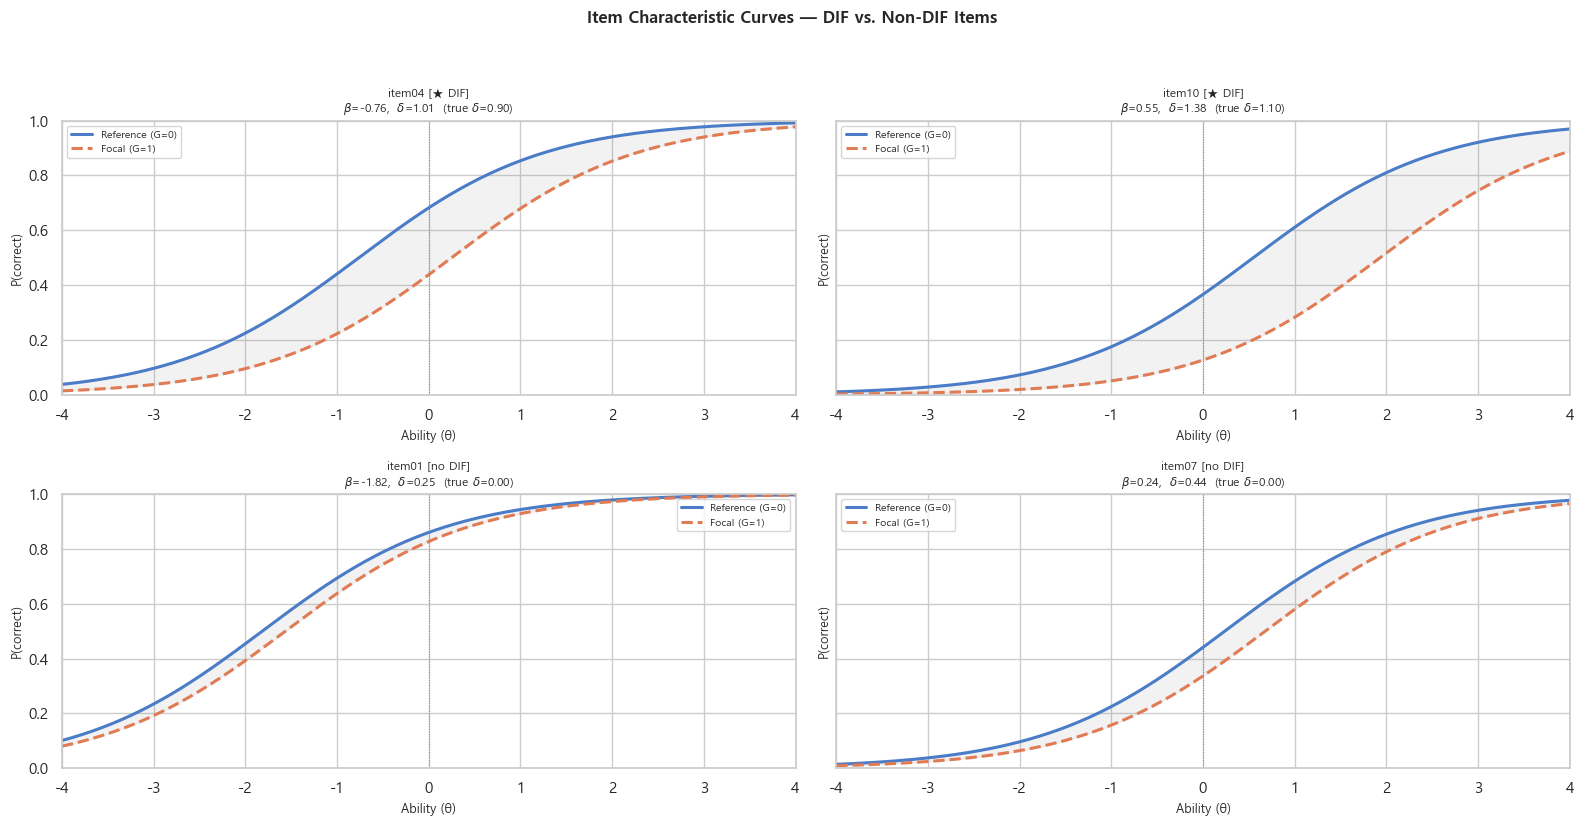

In [19]:
theta_range = np.linspace(-4, 4, 300)

# 2 DIF items + 2 non-DIF items (0-indexed)
display_items = [3, 9, 0, 6]   # items 4, 10 (DIF) and 1, 7 (no DIF)

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharey=True)
axes = axes.flatten()

for ax, j in zip(axes, display_items):
    row  = delta_summary_df[delta_summary_df.item_no == j + 1].iloc[0]
    brow = beta_summary_df.iloc[j]
    b_hat = brow["post_mean"]
    d_hat = row["post_mean"]
    d_true = true_delta[j]

    p_ref   = expit(theta_range - b_hat)
    p_focal = expit(theta_range - b_hat - d_hat)

    ax.plot(theta_range, p_ref,   color="#4a7cc7", lw=2.2,
            label="Reference (G=0)")
    ax.plot(theta_range, p_focal, color="#e07b54", lw=2.2,
            linestyle="--", label="Focal (G=1)")
    ax.fill_between(theta_range, p_ref, p_focal, alpha=0.10, color="gray")

    dif_flag = "★ DIF" if true_delta[j] != 0 else "no DIF"
    ax.set_title(
        f"item{j+1:02d} [{dif_flag}]\n"
        f"$\\beta$={b_hat:.2f},  $\\delta$={d_hat:.2f}  (true $\\delta$={d_true:.2f})",
        fontsize=8.5
    )
    ax.set_xlabel("Ability (θ)", fontsize=9)
    ax.set_ylabel("P(correct)", fontsize=9)
    ax.axvline(0, color="gray", lw=0.7, linestyle=":")
    ax.set_xlim(-4, 4); ax.set_ylim(0, 1)
    ax.legend(fontsize=7.5)

fig.suptitle("Item Characteristic Curves — DIF vs. Non-DIF Items",
             fontsize=12, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("icc_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

## 10. Visualise DIF Magnitude — Forest Plot

A **forest plot** of all $\delta_j$ posterior means with 90% credible intervals.  
- **Red diamonds** — items flagged as DIF ($P(|\delta_j| \geq 0.2) \geq 0.80$)  
- **Blue diamonds** — items not flagged  
- **Black tick marks** — true $\delta_j$ values (injected in simulation)  
- **Dashed grey lines** — the $\pm 0.2$ effect-size boundary

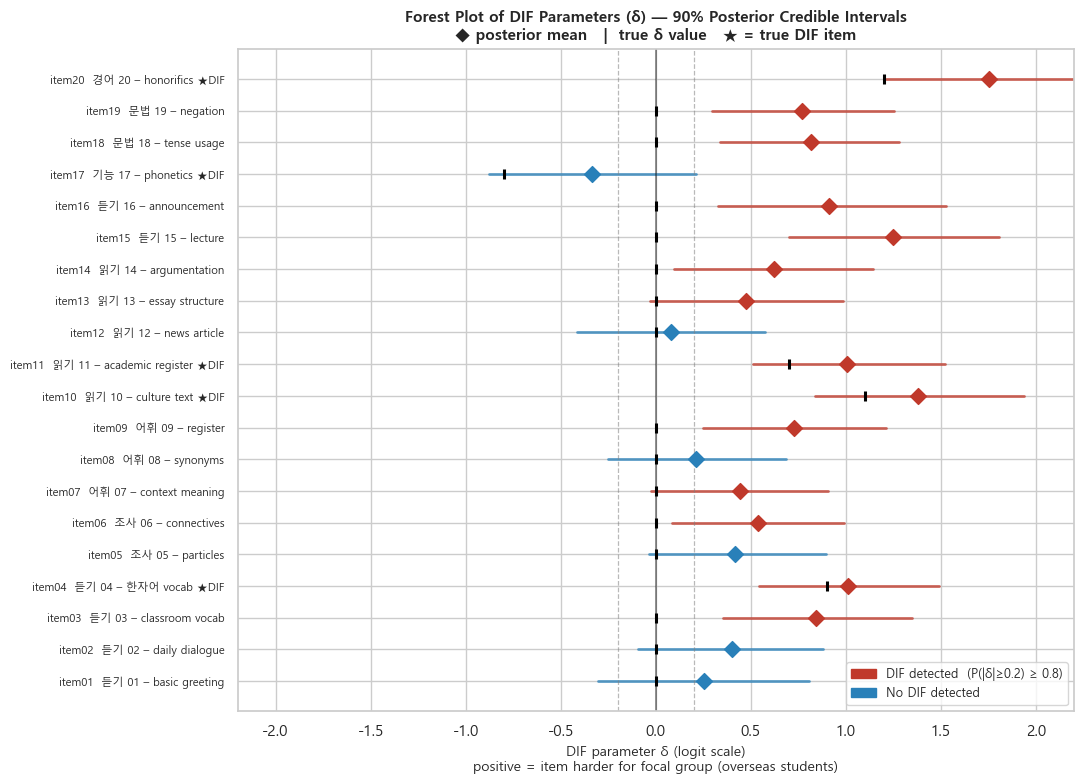

In [15]:
fig, ax = plt.subplots(figsize=(11, 8))

y_pos  = np.arange(N_ITEMS)
colors = ["#c0392b" if row.DIF_detected else "#2980b9"
          for _, row in delta_summary_df.iterrows()]

for i, (_, row) in enumerate(delta_summary_df.iterrows()):
    # 90% CI bar
    ax.plot([row["q05"], row["q95"]], [i, i],
            color=colors[i], lw=2.0, alpha=0.75, solid_capstyle="round")
    # Posterior mean marker
    ax.scatter(row["post_mean"], i, color=colors[i], s=65, zorder=5, marker="D")
    # True value marker
    ax.scatter(row["true_value"], i, color="black",
               s=50, zorder=6, marker="|", linewidths=2.2)

# Reference lines
ax.axvline(0,    color="black", lw=1.3, linestyle="-",  alpha=0.45)
ax.axvline( 0.2, color="gray",  lw=0.9, linestyle="--", alpha=0.55)
ax.axvline(-0.2, color="gray",  lw=0.9, linestyle="--", alpha=0.55)

ax.set_yticks(y_pos)
ax.set_yticklabels(
    [f"item{j+1:02d}  {item_labels[j][:35]}" for j in range(N_ITEMS)],
    fontsize=8
)
ax.set_xlabel(
    "DIF parameter δ (logit scale)\n"
    "positive = item harder for focal group (overseas students)",
    fontsize=10
)
ax.set_title(
    "Forest Plot of DIF Parameters (δ) — 90% Posterior Credible Intervals\n"
    "◆ posterior mean   |  true δ value   ★ = true DIF item",
    fontsize=11, fontweight="bold"
)

patch_dif   = mpatches.Patch(color="#c0392b",
                              label=f"DIF detected  (P(|δ|≥0.2) ≥ {THRESHOLD_PROB})")
patch_nodif = mpatches.Patch(color="#2980b9", label="No DIF detected")
ax.legend(handles=[patch_dif, patch_nodif], loc="lower right", fontsize=9)
ax.set_xlim(-2.2, 2.2)

plt.tight_layout()
plt.savefig("dif_forest_plot.png", dpi=130, bbox_inches="tight")
plt.show()

In [16]:
# ── Final Recovery / Performance Summary ─────────────────────────────────────
tp = (delta_summary_df["classification"] == "True Positive").sum()
fp = (delta_summary_df["classification"] == "False Positive").sum()
fn = (delta_summary_df["classification"] == "False Negative").sum()
tn = (delta_summary_df["classification"] == "True Negative").sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
recall    = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else float("nan")

print("╔══════════════════════════════════════════════════════════════════╗")
print("║         DIF SIMULATION — RECOVERY SUMMARY                      ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  True Positives  (correct detections)    : {tp:>2d} / {len(DIF_ITEMS)}             ║")
print(f"║  False Positives (spurious flags)         : {fp:>2d}                    ║")
print(f"║  False Negatives (missed DIF items)       : {fn:>2d}                    ║")
print(f"║  True Negatives  (correct non-DIF items)  : {tn:>2d} / {N_ITEMS - len(DIF_ITEMS)}            ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  Precision : {precision:.2f}    Recall : {recall:.2f}    F1 : {f1:.2f}              ║")
print("╚══════════════════════════════════════════════════════════════════╝")

print("\n── Parameter Recovery (δ): True vs Estimated ──")
print(delta_summary_df[["item_label","description","true_value","post_mean",
                          "q05","q95","DIF_detected","classification"]]
      .to_string(index=False))

╔══════════════════════════════════════════════════════════════════╗
║         DIF SIMULATION — RECOVERY SUMMARY                      ║
╠══════════════════════════════════════════════════════════════════╣
║  True Positives  (correct detections)    :  4 / 5             ║
║  False Positives (spurious flags)         : 10                    ║
║  False Negatives (missed DIF items)       :  1                    ║
║  True Negatives  (correct non-DIF items)  :  5 / 15            ║
╠══════════════════════════════════════════════════════════════════╣
║  Precision : 0.29    Recall : 0.80    F1 : 0.42              ║
╚══════════════════════════════════════════════════════════════════╝

── Parameter Recovery (δ): True vs Estimated ──
item_label                    description  true_value  post_mean    q05   q95  DIF_detected classification
    item01         듣기 01 – basic greeting         0.0      0.252 -0.303 0.808         False  True Negative
    item02         듣기 02 – daily dialogue         0.0   